# Adult Income - Model Training & Evaluation

This notebook trains, tunes, and evaluates multiple machine learning classifiers to predict income levels. It compares models based on Accuracy, F1 Score, and ROC-AUC.

## Contents
1. Load Data
2. Logistic Regression
3. K-Nearest Neighbors (KNN)
4. Decision Tree
5. Naive Bayes
6. Support Vector Machine (SVM)
7. Random Forest
8. Gradient Boosting
9. All Models Comparison

In [60]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [61]:
sns.set_theme(style='darkgrid')

# 1. Load Data

In [62]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

X_train = train.drop('income', axis=1)
y_train = train['income']

X_test = test.drop('income', axis=1)
y_test = test['income']

In [63]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23276 entries, 0 to 23275
Data columns (total 53 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   num__age                                   23276 non-null  float64
 1   num__education.num                         23276 non-null  float64
 2   num__capital.gain                          23276 non-null  float64
 3   num__capital.loss                          23276 non-null  float64
 4   num__hours.per.week                        23276 non-null  float64
 5   cat__workclass_Federal-gov                 23276 non-null  float64
 6   cat__workclass_Private                     23276 non-null  float64
 7   cat__workclass_Self-emp-inc                23276 non-null  float64
 8   cat__workclass_Self-emp-not-inc            23276 non-null  float64
 9   cat__workclass_State/Local-gov             23276 non-null  float64
 10  cat__workclass_Unknown

In [64]:
evaluations = {'Logistic Regression': [],
               'KNN': [],
               'Decision Tree': [],
               'Naive Bayes': [],
               'SVM': [],
               'Random Forest': [],
               'Gradient Boosting': []
               }

# 2. Logistic Regression

In [65]:
logistic_params = {"C": [0.01, 0.1, 1, 10, 100]}

logistic_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    logistic_params,
    cv=5,
    scoring="accuracy"
 )

logistic_grid.fit(X_train, y_train)

print(f"Best Logistic Regression Parameters: {logistic_grid.best_params_}")
print(f"Best Logistic Regression CV Accuracy: {logistic_grid.best_score_ * 100:.2f}")

Best Logistic Regression Parameters: {'C': 1}
Best Logistic Regression CV Accuracy: 84.55


In [66]:
logistic_model = LogisticRegression(max_iter=1000, **logistic_grid.best_params_)

logistic_cv = cross_val_score(logistic_model , X_train , y_train , cv=5)

logistic_model.fit(X_train , y_train)
logistic_pred = logistic_model.predict(X_test)

evaluations['Logistic Regression'].append(accuracy_score(y_test ,logistic_pred))
evaluations['Logistic Regression'].append(f1_score(y_test ,logistic_pred))

Evaluation

Accuracy: 84.95
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4378
           1       0.74      0.60      0.66      1442

    accuracy                           0.85      5820
   macro avg       0.81      0.77      0.78      5820
weighted avg       0.84      0.85      0.84      5820



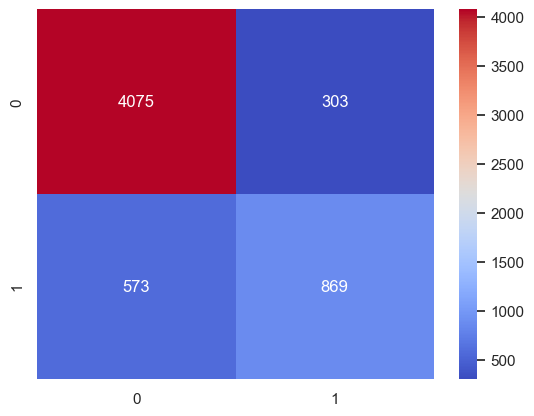

In [67]:
print(f"Accuracy: {evaluations['Logistic Regression'][0] * 100:.2f}")
print(classification_report(y_test , logistic_pred))

sns.heatmap(confusion_matrix(y_test , logistic_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# 3. KNN

In [68]:
knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring="accuracy"
 )

knn_grid.fit(X_train, y_train)

print(f"Best KNN Parameters: {knn_grid.best_params_}")
print(f"Best KNN CV Accuracy: {knn_grid.best_score_ * 100:.2f}")

Best KNN Parameters: {'n_neighbors': 11}
Best KNN CV Accuracy: 83.18


In [69]:
knn_model = KNeighborsClassifier(**knn_grid.best_params_)

knn_cv = cross_val_score(knn_model , X_train , y_train , cv=5)

knn_model.fit(X_train , y_train)
knn_pred = knn_model.predict(X_test)

evaluations['KNN'].append(accuracy_score(y_test, knn_pred))
evaluations['KNN'].append(f1_score(y_test, knn_pred))

Evaluation

Accuracy: 83.52
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      4378
           1       0.70      0.59      0.64      1442

    accuracy                           0.84      5820
   macro avg       0.78      0.75      0.77      5820
weighted avg       0.83      0.84      0.83      5820



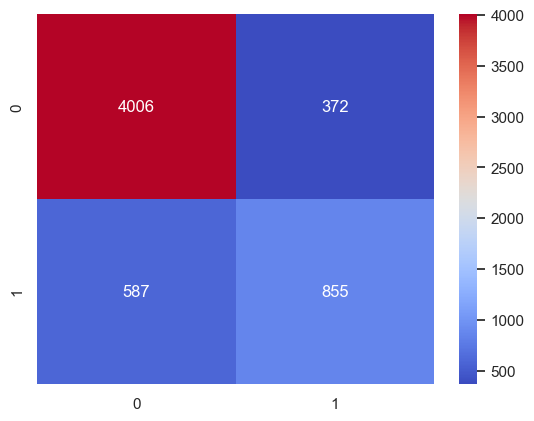

In [70]:
print(f"Accuracy: {evaluations['KNN'][0] * 100:.2f}")
print(classification_report(y_test, knn_pred))

sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# 4. Decision Tree

In [71]:
dt_params = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="accuracy"
 )

dt_grid.fit(X_train, y_train)

print(f"Best Decision Tree Parameters: {dt_grid.best_params_}")
print(f"Best Decision Tree CV Accuracy: {dt_grid.best_score_ * 100:.2f}")

Best Decision Tree Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Decision Tree CV Accuracy: 84.74


In [72]:
dt_model = DecisionTreeClassifier(random_state=42, **dt_grid.best_params_)

dt_cv = cross_val_score(dt_model, X_train, y_train, cv=5)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

evaluations['Decision Tree'].append(accuracy_score(y_test, dt_pred))
evaluations['Decision Tree'].append(f1_score(y_test, dt_pred))

Evaluation

Accuracy: 84.33
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      4378
           1       0.70      0.64      0.67      1442

    accuracy                           0.84      5820
   macro avg       0.79      0.77      0.78      5820
weighted avg       0.84      0.84      0.84      5820



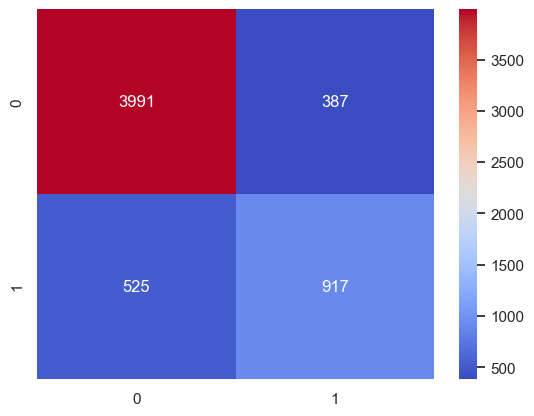

In [73]:
print(f"Accuracy: {evaluations['Decision Tree'][0] * 100:.2f}")
print(classification_report(y_test, dt_pred))

sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# 5. Naive Bayes

In [74]:
nb_params = {
    "var_smoothing": np.logspace(0, -9, num=10)
}

nb_grid = GridSearchCV(
    GaussianNB(),
    nb_params,
    cv=5,
    scoring="accuracy"
 )

nb_grid.fit(X_train, y_train)

print(f"Best Naive Bayes Parameters: {nb_grid.best_params_}")
print(f"Best Naive Bayes CV Accuracy: {nb_grid.best_score_ * 100:.2f}")

Best Naive Bayes Parameters: {'var_smoothing': np.float64(1.0)}
Best Naive Bayes CV Accuracy: 79.51


In [75]:
nb_model = GaussianNB(**nb_grid.best_params_)

nb_cv = cross_val_score(nb_model, X_train, y_train, cv=5)

nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

evaluations['Naive Bayes'].append(accuracy_score(y_test, nb_pred))
evaluations['Naive Bayes'].append(f1_score(y_test, nb_pred))

Evaluation

Accuracy: 79.26
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      4378
           1       0.74      0.25      0.37      1442

    accuracy                           0.79      5820
   macro avg       0.77      0.61      0.62      5820
weighted avg       0.78      0.79      0.75      5820



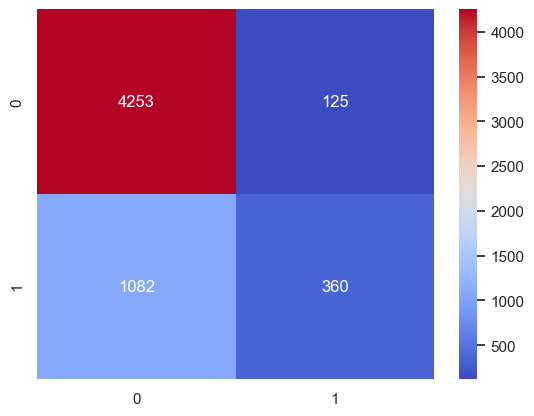

In [76]:
print(f"Accuracy: {evaluations['Naive Bayes'][0] * 100:.2f}")
print(classification_report(y_test, nb_pred))

sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# 6. SVM

In [77]:
svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

svm_grid = GridSearchCV(
    SVC(),
    svm_params,
    cv=5,
    scoring="accuracy",
)

svm_grid.fit(X_train, y_train)

print(f"Best SVM Parameters: {svm_grid.best_params_}")
print(f"Best SVM CV Accuracy: {svm_grid.best_score_ * 100:.2f}")

Best SVM Parameters: {'C': 1, 'kernel': 'rbf'}
Best SVM CV Accuracy: 85.06


In [78]:
svm_model= SVC(**svm_grid.best_params_)

svm_cv = cross_val_score(svm_model, X_train, y_train)

svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

evaluations['SVM'].append(accuracy_score(y_test, svm_pred))
evaluations['SVM'].append(f1_score(y_test, svm_pred))

Evaluation

Accuracy: 0.8537800687285223
              precision    recall  f1-score   support

           0       0.87      0.94      0.91      4378
           1       0.78      0.58      0.66      1442

    accuracy                           0.85      5820
   macro avg       0.82      0.76      0.78      5820
weighted avg       0.85      0.85      0.85      5820



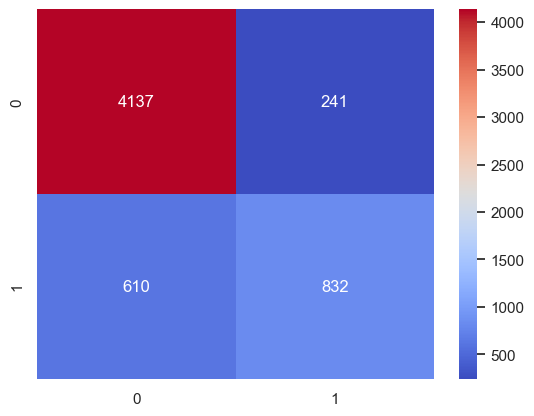

In [79]:
print(f"Accuracy: {evaluations['SVM'][0]}")
print(classification_report(y_test, svm_pred))

sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# 7. Random Forest

In [80]:
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(f"Best Random Forest Parameters: {rf_grid.best_params_}")
print(f"Best Random Forest CV Accuracy: {rf_grid.best_score_ * 100:.2f}")

Best Random Forest Parameters: {'max_depth': 20, 'n_estimators': 200}
Best Random Forest CV Accuracy: 85.71


In [81]:
rf_model = RandomForestClassifier(random_state=42, **rf_grid.best_params_, )

rf_cv = cross_val_score(rf_model, X_train, y_train, cv=5)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

evaluations['Random Forest'].append(accuracy_score(y_test, rf_pred))
evaluations['Random Forest'].append(f1_score(y_test, rf_pred))

Evaluation

Accuracy: 85.86
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4378
           1       0.79      0.59      0.67      1442

    accuracy                           0.86      5820
   macro avg       0.83      0.77      0.79      5820
weighted avg       0.85      0.86      0.85      5820



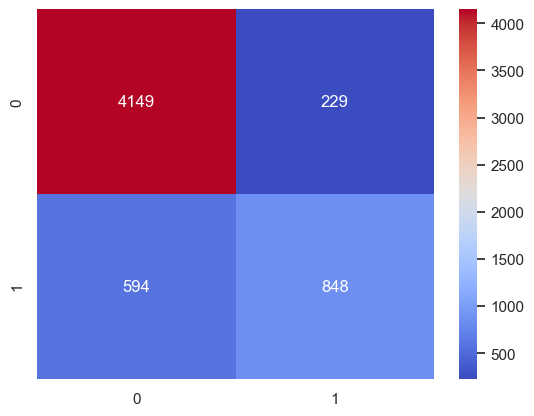

In [82]:
print(f"Accuracy: {evaluations['Random Forest'][0] * 100:.2f}")
print(classification_report(y_test, rf_pred))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# 8. Gradient Boosting

In [83]:
gb_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print(f"Best Gradient Boosting Parameters: {gb_grid.best_params_}")
print(f"Best Gradient Boosting CV Accuracy: {gb_grid.best_score_ * 100:.2f}")

Best Gradient Boosting Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Best Gradient Boosting CV Accuracy: 86.87


In [84]:
gb_model = GradientBoostingClassifier(random_state=42, **gb_grid.best_params_)

gb_cv = cross_val_score(gb_model, X_train, y_train, cv=5)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

evaluations['Gradient Boosting'].append(accuracy_score(y_test, gb_pred))
evaluations['Gradient Boosting'].append(f1_score(y_test, gb_pred))

Evaluation

Accuracy: 87.23
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4378
           1       0.80      0.65      0.72      1442

    accuracy                           0.87      5820
   macro avg       0.84      0.80      0.82      5820
weighted avg       0.87      0.87      0.87      5820



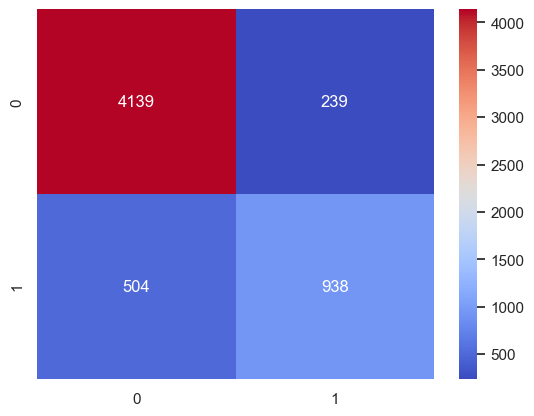

In [85]:
print(f"Accuracy: {evaluations['Gradient Boosting'][0] * 100:.2f}")
print(classification_report(y_test, gb_pred))

sns.heatmap(confusion_matrix(y_test, gb_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# All Models Comparison

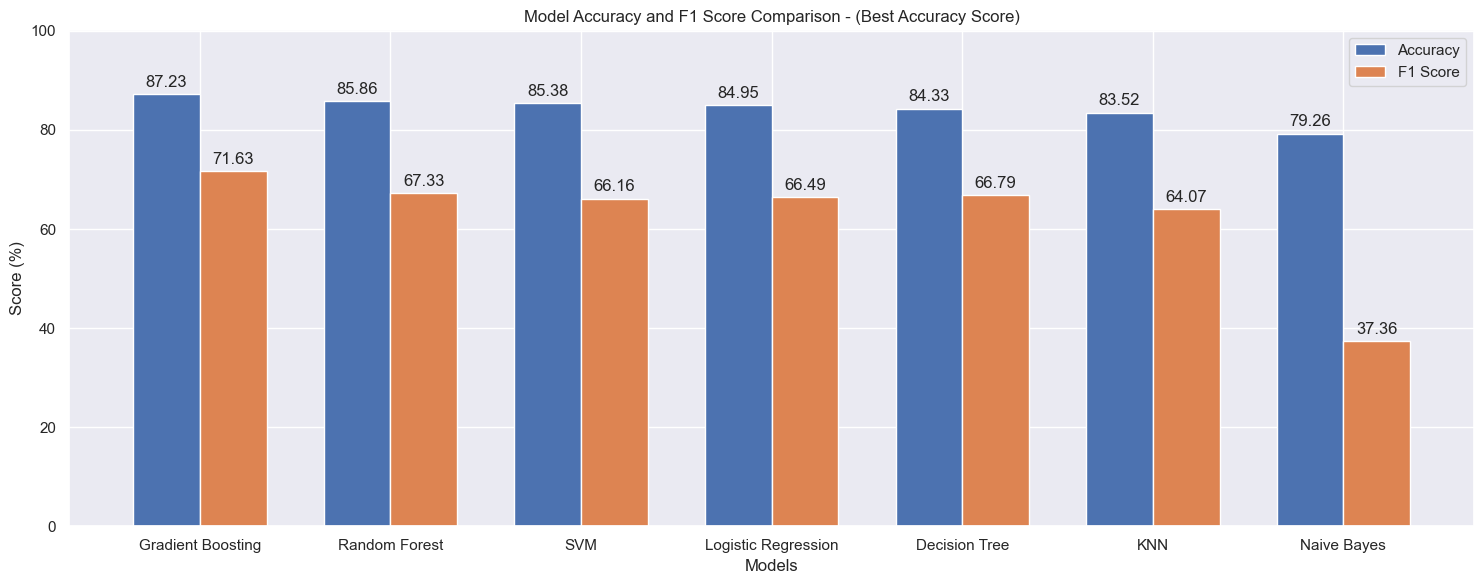

In [86]:
evaluated_models = evaluations.keys()

accuracies = np.array([
    evaluations[model][0] for model in evaluated_models
]) * 100

f1_scores = np.array([
    evaluations[model][1] for model in evaluated_models
]) * 100

# Create one DataFrame with both metrics
results = pd.DataFrame({
    "Model": evaluated_models,
    "Accuracy (%)": accuracies,
    "F1 Score (%)": f1_scores
})

# Sort by accuracy: highest to lowest
results = results.sort_values(by="Accuracy (%)", ascending=False)
results.to_csv('../data/models_best_acc.csv', index=False)

# Plot both metrics together
x = np.arange(len(results))
width = 0.35

plt.figure(figsize=(15, 6))

accuracy_bars = plt.bar(
    x - width / 2,
    results["Accuracy (%)"],
    width,
    label="Accuracy"
)
f1_bars = plt.bar(
    x + width / 2,
    results["F1 Score (%)"],
    width,
    label="F1 Score"
)

plt.bar_label(accuracy_bars, fmt="%.2f", padding=3)
plt.bar_label(f1_bars, fmt="%.2f", padding=3)

plt.xlabel("Models")
plt.ylabel("Score (%)")
plt.title("Model Accuracy and F1 Score Comparison - (Best Accuracy Score)")
plt.xticks(x, results["Model"])
plt.ylim(0, 100.1)
plt.legend()
plt.tight_layout()
plt.show()